# Assignment 1
Nina Kesel 
CS4379G.251

**Dataset:** Kaggle “Netflix Movies and TV Shows” (`netflix_titles.csv`)  
Dataset page: https://www.kaggle.com/datasets/shivamb/netflix-shows <br>

**Question:** How has the number of titles added to Netflix changed over time (by year) <br>




## Imports and dataset set up: 

In [1]:
import os
from pathlib import Path
import subprocess
import zipfile

DATA_DIR = Path("data/netflix")
DATA_DIR.mkdir(parents=True, exist_ok=True)

csv_path = DATA_DIR / "netflix_titles.csv"

if csv_path.exists():
    print("✅ Found:", csv_path)
else:
    print("netflix_titles.csv not found. Attempting Kaggle download...")
    print("If this fails, use manual download (Option A).")

✅ Found: data/netflix/netflix_titles.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 0
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

DATA_DIR = Path("data/netflix")
CSV_PATH = DATA_DIR / "netflix_titles.csv"

## Data Loading: 

In [3]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CSV_PATH}.\n"
        "Download from Kaggle (manual) or run the Kaggle API download cell above."
    )

df = pd.read_csv(CSV_PATH)
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## Data Dictionary: 
- show_id: A unique ID given to each entry<br>
- type: Weather the entry is a Tv Show or a Movie<br>
- title: The title of the show or movie<br>
- director: The director of the movie<br>
- cast: List of people in the movie or tv show<br>
- country: The country of creation<br>
- date_added: The date the title was added to netflix<br>
- release_year: The year the title was created<br>
- rating: The content rating of the title<br>
- durration: The length of the title in time or in seasons<br>
- listed_in: The location/catagory of the title in Netflix<br>
- description: A discription of the title<br>

## Data Cleaning:

In [7]:
df.isna().sum().sort_values(ascending=False).head(12)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [8]:
df.duplicated().any()

np.False_

In [9]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

df[["title", "type", "date_added", "year_added"]].head(10)

,title,type,date_added,year_added
0,Dick Johnson Is Dead,Movie,2021-09-25,2021.0
1,Blood & Water,TV Show,2021-09-24,2021.0
2,Ganglands,TV Show,2021-09-24,2021.0
3,Jailbirds New Orleans,TV Show,2021-09-24,2021.0
4,Kota Factory,TV Show,2021-09-24,2021.0
5,Midnight Mass,TV Show,2021-09-24,2021.0
6,My Little Pony: A New Generation,Movie,2021-09-24,2021.0
7,Sankofa,Movie,2021-09-24,2021.0
8,The Great British Baking Show,TV Show,2021-09-24,2021.0
9,The Starling,Movie,2021-09-24,2021.0


## Analysis

### Trends over time of how may titles where added per year.

In [10]:
# number of titles added per year
added_per_year = df.dropna(subset=["year_added"]).groupby("year_added").size()
added_per_year

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
dtype: int64

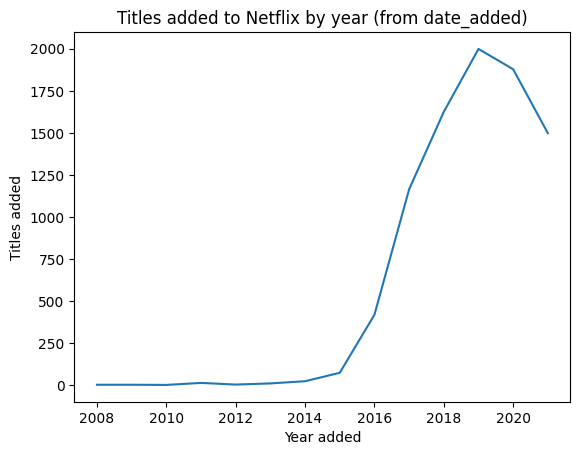

In [11]:
plt.figure()
plt.plot(added_per_year.index, added_per_year.values)
plt.xlabel("Year added")
plt.ylabel("Titles added")
plt.title("Titles added to Netflix by year (from date_added)")
plt.show()

This graph is showing the total number of titles that where added to netflix from the years 2008 t0 2021. The graph showss that there is an exponential increase starting around 2015 and peaking around 2018. We can also see that the total number of added titles starts decreasing around the later half of 2019 and continues a downward trend into 2021. 

In [12]:
# how many movies and TV shows added per year
type_counts = df.groupby(['year_added', 'type']).size()
comparison = type_counts
type_counts

year_added  type   
2008.0      Movie         1
            TV Show       1
2009.0      Movie         2
2010.0      Movie         1
2011.0      Movie        13
2012.0      Movie         3
2013.0      Movie         6
            TV Show       4
2014.0      Movie        19
            TV Show       4
2015.0      Movie        56
            TV Show      17
2016.0      Movie       253
            TV Show     165
2017.0      Movie       839
            TV Show     325
2018.0      Movie      1237
            TV Show     388
2019.0      Movie      1424
            TV Show     575
2020.0      Movie      1284
            TV Show     594
2021.0      Movie       993
            TV Show     505
dtype: int64

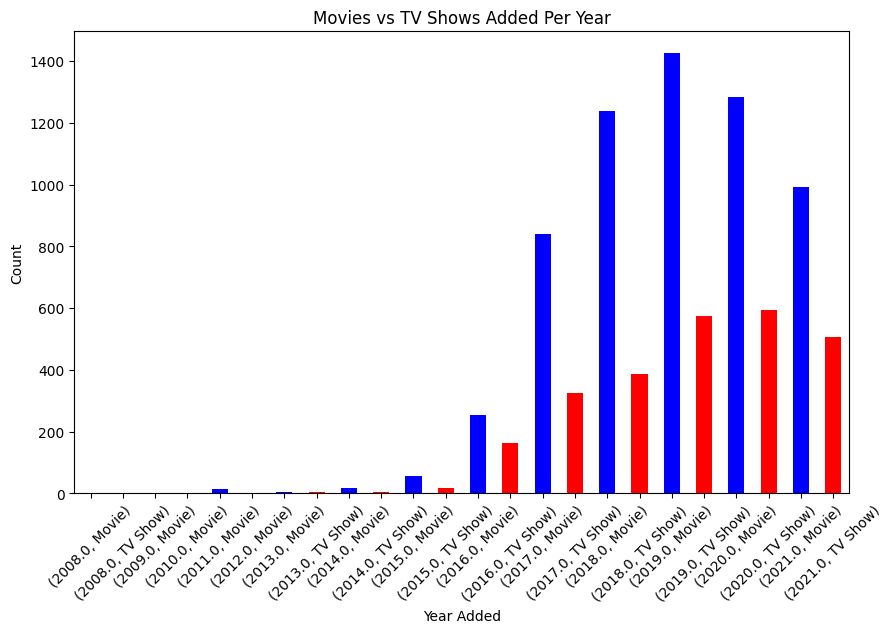

In [13]:
comparison.plot(
    kind='bar',
    figsize=(10,6),
    color=['blue', 'red'],
)

plt.title('Movies vs TV Shows Added Per Year')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The bar graph above is the visualization of the comparison of the two different titles in Nexflix, Movies and TV Shows and their increase from the years 2008 to 2021. From this chart we can determine that overall movies make up a larger percentage of the new catalog year per year on netflix when compared to TV shows. We can also see that TV shows did not start being added to nexflix untill 2013 and the size of the catalog starts drastically increasing after 2015. We can also see that while movie titles seem to have hit a peak in 2019, TV shows are still increasing dispite not being added in the same quantities as movies. 